# Katastrophensimulation - batch-run und Analyse
## Eigene Erweiterung des Systems [Aufgabe 6]

Als Erweiterung des Systems rund um die Simulation wählten wir eine erweiterte Auswertung des Systems.
Dafür nutzten wir die von Mesa bereitgestellten **batch-run** Möglichkeiten, mit welchen die Simulationen sehr oft und effizient ausgeführt werden konnten.
Anschließend wurden die generierten Daten mit **Pandas** in passende Formate umgewandelt und mit **Seaborn** (auf Matplotlib aufbauend) visualisiert.

In [10]:
import seaborn as sns
from schema import *
from typing import Dict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
BATCH_RUN_PKL = "./output/batch_results.pkl"
SAFEZONE_DATA_PKL = "./output/safezone_data.pkl"
import time

## Aufsetzen des batch-runs

Für den batch-run können Paramter als Dictionary übergeben werden. Wenn die Parameter keine konstanten Werte, sondern Listen sind, so werden alle möglichen Kombinationen der Parameter durchlaufen. Schnell kann es dadurch zu tausenden Durchläufen kommen. 

In [11]:
# if iterables: tries all possible combinations of the parameters
parameters: Dict = {
    "width": range(8, 21, 2),
    "height": range(8, 21, 2),
    "n_survivors": range(1, 11),
    "n_safe_zones": range(1, 11),
    "n_robot_agents": range(1, 7),
    "seed": 42,
}
# parameters: Dict = {
#     "width": range(8, 13, 2),
#     "height": range(8, 13, 2),
#     "n_survivors": 4,
#     "n_safe_zones": [3, 6],
#     "n_robot_agents": 1,
#     "seed": 42,
# }

# calculate the number of iterations for all parameters
count = 1
for key, value in parameters.items():
    # value can be a list or a range
    if isinstance(value, range):
        count *= len(list(value))
    elif isinstance(value, list):
        count *= len(value)
print("Count of combinations:", count)

Count of combinations: 29400


Mit Multiprocessing (Parameter _number\_processes_ von batch_run()) können jedoch mehrere Simulationen gleichzeitig ausgeführt werden, was die Simulationszeit deutlich reduziert. 
_Beispiel für den batch-run: 48600 Simulationen in 1:01:33 ergeben ca. 13 Simulationen pro Sekunde bei der Verwendung von zwölf logischen Prozessoren._

Besonders auffällig ist die hohe Geschwindigkeit der Simulationen bei geringen Höhen und Breiten des Labyrinths im Vergleich zu den hohen Rechendauern bei großen Labyrinthflächen. Vermutlich tritt dieser Unterschied wegen des erhöhten Rechenaufwands beim A-Stern Algorithmus für große Pfadlängen, wie es sie offensichtlich öfter bei großen Labyrinthen gibt, auf. 

Die Daten werden zur Aufbewahrung in einer pickle-Datei gespeichert und nur bei _run\_batch = True_ überschrieben.

In [12]:
# if true -> run batch, safe to pickle file in output folder
# if false -> load pickle file from output folder
run_batch = False

In [13]:
if run_batch:
    batch_results = mesa.batch_run(
        model_cls=EnvironmentModel,
        parameters=parameters,
        iterations=4, # for each possible combination of parameters
        number_processes=None,
        data_collection_period=-1,
        display_progress=True,
        max_steps=1000,
    )

In [14]:
df: pd.DataFrame = None

if run_batch:
    # safe results to pickle file
    df = pd.DataFrame(batch_results)
    pd.DataFrame.to_pickle(df, BATCH_RUN_PKL)
else:
    # load the results from the pickle file
    try:
        df = pd.DataFrame(pd.read_pickle(BATCH_RUN_PKL))
    except:
        print("batch results not available, file not found, etc.")

print(f"The results have {len(df)} rows and {len(df.columns)} columns.")
print(df.columns)
df.head(2)

The results have 205800 rows and 30 columns.
Index(['RunId', 'iteration', 'Step', 'width', 'height', 'n_survivors',
       'n_safe_zones', 'n_robot_agents', 'seed', 'Maze', 'Survivors',
       'SafeZones', 'MazeWidth', 'MazeHeight', 'AllSurvivorsRescued',
       'InitialPathlengths', 'MeanWallDensity', 'NorthSouthSymmetry',
       'EastWestSymmetry', 'ExitCount', 'TotalTilesMoved',
       'TotalSurvivorsPickedUp', 'TotalSurvivorsPlacedDown', 'AgentID', 'Tile',
       'TransportedSurvivor', 'TilesMoved', 'SurvivorsPickedUp',
       'SurvivorsPlacedDown', 'StillRunning'],
      dtype='object')


,RunId,iteration,Step,width,height,n_survivors,n_safe_zones,n_robot_agents,seed,Maze,...,TotalTilesMoved,TotalSurvivorsPickedUp,TotalSurvivorsPlacedDown,AgentID,Tile,TransportedSurvivor,TilesMoved,SurvivorsPickedUp,SurvivorsPlacedDown,StillRunning
0,4,0,4,8,8,1,1,5,42,"{(0, 0): {'N': 0, 'E': 1, 'S': 1, 'W': 1}, (1,...",...,12,5,0,1,<schema.Tile object at 0x0000021C9BCBE6F0>,None,12,1,1,True
1,4,0,4,8,8,1,1,5,42,"{(0, 0): {'N': 0, 'E': 1, 'S': 1, 'W': 1}, (1,...",...,12,5,0,2,<schema.Tile object at 0x0000021C9BCBE750>,<schema.Survivor object at 0x0000021CA17F2FF0>,0,1,0,False


## Data transformation

Die Daten werden mit Pandas in einem DataFrame für die Verwendung angepasst.

In [15]:
df.drop(
    [
        "seed", 
        "MazeWidth", 
        "MazeHeight", 
        "AllSurvivorsRescued", 
        "Tile", 
        "StillRunning",
        "AgentID",
        "TransportedSurvivor",
        "TilesMoved"
    ],
    axis=1,
    inplace=True,
)
print(f"The results have reduced {len(df.columns)} columns.")
print(df.columns)

# height * width
df["MazeArea"] = df.apply(lambda x: x["width"] * x["height"], axis=1)

# get pathlengths parameters. only works if data_collection_period is set to 1
df["PathlengthMin"] = df.apply(
    lambda x: EnvironmentModel.get_min_pathlength(x["InitialPathlengths"]),
    axis=1,
)
df["PathlengthMax"] = df.apply(
    lambda x: EnvironmentModel.get_max_pathlength(x["InitialPathlengths"]),
    axis=1,
)
df["PathlengthMean"] = df.apply(
    lambda x: EnvironmentModel.get_mean_pathlength(x["InitialPathlengths"]),
    axis=1,
)

# ratios between TilesMoved and parameters
df["TilesMovedPerSurvivor"] = df.apply(
    lambda x: x["TotalTilesMoved"] / x["n_survivors"] if x["n_survivors"] > 0 else 0, axis=1
)

df["TilesMovedPerSafeZone"] = df.apply(
    lambda x: x["TotalTilesMoved"] / x["n_safe_zones"] if x["n_safe_zones"] > 0 else 0,
    axis=1,
)

df["TilesMovedPerArea"] = df.apply(
    lambda x: x["TotalTilesMoved"] / x["MazeArea"] if x["MazeArea"] > 0 else 0,
    axis=1,
)
df["TilesMovedPerHeight"] = df.apply(
    lambda x: x["TotalTilesMoved"] / x["height"] if x["height"] > 0 else 0,
    axis=1,
)

df["PathlengthMinPerArea"] = df.apply(
    lambda x: x["PathlengthMin"] / x["MazeArea"] if x["MazeArea"] > 0 else 0,
    axis=1,
)
df["PathlengthMaxPerArea"] = df.apply(
    lambda x: x["PathlengthMax"] / x["MazeArea"] if x["MazeArea"] > 0 else 0,
    axis=1,
)
df["PathlengthMeanPerArea"] = df.apply(
    lambda x: x["PathlengthMean"] / x["MazeArea"] if x["MazeArea"] > 0 else 0,
    axis=1,
)

# grouping of survivor / safe zone / robot counts
df["SurvivorCountGroup"] = df.apply(
    lambda x: "Low (<5)" if x["n_survivors"] < 5 else "High (>=5)", axis=1
)
df["SafeZoneCountGroup"] = df.apply(
    lambda x: "Low (<5)" if x["n_safe_zones"] < 5 else "High (>=5)", axis=1
)
df["RobotCountGroup"] = df.apply(
    lambda x: "Low (<4)" if x["n_robot_agents"] < 3 else "High (>=4)", axis=1
)

The results have reduced 21 columns.
Index(['RunId', 'iteration', 'Step', 'width', 'height', 'n_survivors',
       'n_safe_zones', 'n_robot_agents', 'Maze', 'Survivors', 'SafeZones',
       'InitialPathlengths', 'MeanWallDensity', 'NorthSouthSymmetry',
       'EastWestSymmetry', 'ExitCount', 'TotalTilesMoved',
       'TotalSurvivorsPickedUp', 'TotalSurvivorsPlacedDown',
       'SurvivorsPickedUp', 'SurvivorsPlacedDown'],
      dtype='object')


## Data analysis
### Korrelationsmatrix

Mit einem [Seaborn-Beispiel](https://seaborn.pydata.org/archive/0.11/examples/many_pairwise_correlations.html) wird die Korrelationsmatrix der gesammelten Daten visualisiert.


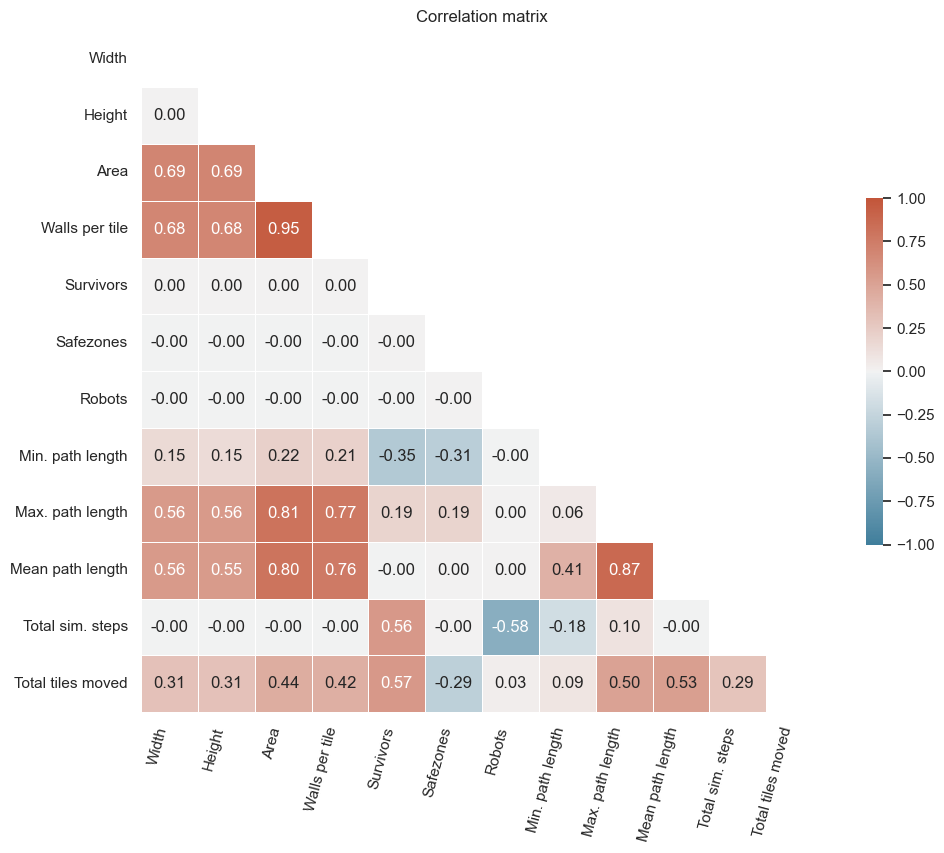

In [16]:
# choose some columns
df_corr = df.reset_index()
df_corr = df_corr[
    [
        "width",
        "height",
        "MazeArea",
        "MeanWallDensity",
        # "NorthSouthSymmetry",
        # "EastWestSymmetry",
        "n_survivors",
        "n_safe_zones",
        "n_robot_agents",
        "PathlengthMin",
        "PathlengthMax",
        "PathlengthMean",
        "Step",
        "TotalTilesMoved",
    ]
]
df_corr.rename(
    columns={
        "width": "Width",
        "height": "Height",
        "MazeArea": "Area",
        "MeanWallDensity": "Walls per tile",
        # "NorthSouthSymmetry": "NS symmetry",
        # "EastWestSymmetry": "EW symmetry",
        "n_survivors": "Survivors",
        "n_safe_zones": "Safezones",
        "n_robot_agents": "Robots",
        "PathlengthMin": "Min. path length",
        "PathlengthMax": "Max. path length",
        "PathlengthMean": "Mean path length",
        "Step": "Total sim. steps",
        "TotalTilesMoved": "Total tiles moved",
    },
    inplace=True,
)

corr = df_corr.corr()

# Correlation matrix with mask for upper triangle
sns.set_theme(style="white")
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True,
    fmt=".2f",
)
plt.title("Correlation matrix")
plt.xticks(rotation=75, ha="right")
plt.savefig("./output/correlation_heatmap.png", dpi=300, bbox_inches="tight");

Aus der **Korrelationsmatrix** werden folgende Zusammenhänge ersichtlich:

### Simulationsschritte
Offensichtlich hängt die Anzahl der **Simulationsschritte** "Total steps" nicht von der Höhe, Breite oder der Anzahl der SafeZones ab, sondern nur von der Anzahl der zu rettenden Überlebenden und der bereitgestellten Roboter. Wäre die Bewegungsreichweite der Roboter pro Simulationsschritt begrenzt, so würde hier eine von den Paramtern dargestellt werden können.

### Wanddichte x Pfadlänge

Interessant ist der Zusammenhang zwischen der Dichte als **Wände pro Feld** des Labyrinths "Walls per tile" mit der maximalen, bzw. durchschnittlichen, **Pfadlänge** "Max/Avg pathlength" mit einem Korrelationskoeffizienten von ca. 0,8.

Visualisiert man den Zusammenhang als Lineplot (siehe unten), so zeigt sich, dass trotz nur minimaler Änderungen der Dichte der Wände pro Feld, die Pfadlängen sehr stark variieren.
Deskriptiv bedeutet das, dass mit steigender Anzahl an (relevanten) Wänden pro Feld, die durchschnittliche und maximale Pfadlänge ansteigt. 

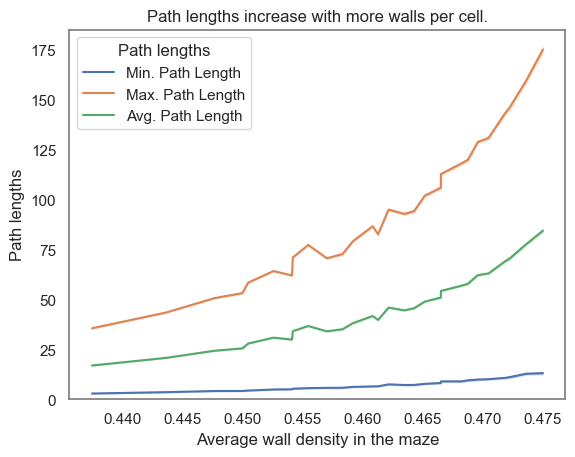

In [17]:
sns.lineplot(data=df, x="MeanWallDensity", y="PathlengthMin", label="Min. Path Length")
sns.lineplot(data=df, x="MeanWallDensity", y="PathlengthMax", label="Max. Path Length")
sns.lineplot(data=df, x="MeanWallDensity", y="PathlengthMean", label="Avg. Path Length")

plt.title("Path lengths increase with more walls per cell.")
plt.xlabel("Average wall density in the maze")
plt.ylabel("Path lengths")
plt.legend(title="Path lengths")

plt.ylim(bottom=0)
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.savefig("./output/wall_density_pathlengths.png", dpi=300, bbox_inches="tight")

Dieses Verhalten wird im Folgenden genauer analysiert:

Normale Passagen (z.B. ein Weg von links nach rechts) haben zwei Wände und zwei offene Wege im Labyrinth. Sackgassen haben drei Wände, von einer Seite kann hergekommen werden. Wege, die zu einer Sackgasse führen, können maximal eine Wand haben, da ein Weg durch sie durchführt und sie eine Abzweigung zur Sackgasse haben. Ausgänge müssen mindestens einen Ort der Herkunft haben, sowie am Rand eine Öffnung, bzw. an einer Ecke zwei Öffnungen. Die Öffnungen zum Rand sind jedoch nicht relevant, da sie nicht zu anderen Feldern zugewandt sind; sie sollten daher nicht mitgezählt werden. Ein Feld an der Ecke kann theoretisch maximal nur zwei relevante Wände haben, da die Wände in das Leere nicht mitgezählt werden. Je mehr Randkästchen vorhanden sind, desto mehr weniger Wände können maximal auftreten.

_Als Beispiel: Ein 2x2 Labyrinth hat vier Felder, wobei zwischen den Feldern maximal vier Wände gesetzt werden können - in diesem Fall wäre das Labyrinth unlösbar. Die acht Wände zu den Rändern werden dabei nicht mitgezählt._

Daraus lässt sich ableiten: Generell sollte sich die durchschnittliche Anzahl der Wände in einem unendlich großen Labyrinth ohne Ausgänge und ohne Sackgassen zwei annähern, da das gesamte Labyrinth eine einzige Passage ohne Abzweigungen und Stops ist und der Einfluss der Ränder nicht mitgezählt wird.
Das verdeutlicht auch der folgende Graph, wobei die Wanddichte die Anzahl der gesetzten Wände pro Feld entsprechen. Die Wanddichte nähert sich somit dem Wert 0,5 an, da gegen unendlich angenähert, zwei von vier Wänden gesetzt sind.

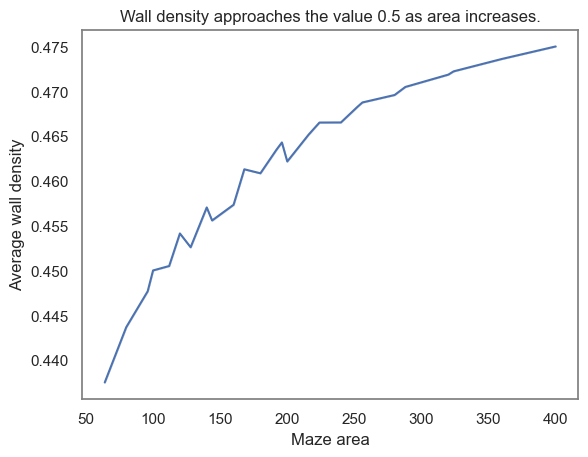

In [18]:
sns.lineplot(data=df, x="MazeArea", y="MeanWallDensity")


plt.title("Wall density approaches the value 0.5 as area increases.")
plt.xlabel("Maze area")
plt.ylabel("Average wall density")

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.savefig("./output/walldensity_per_area_konverging.png", dpi=300, bbox_inches="tight")

Werden die Ränder mitgezählt, also wenn das Labyrinth nicht unendlich groß ist, so wird die durchschnittliche Anzahl der Wände pro Feld unter zwei fallen, da an Randpositionen generell weniger Wände möglich sind. 
_Wenn die Höhe um eins erhöht wird, so steigt die Anzahl der Wände um zwei an, da an der linken und rechten Seite jeweils eine Wand gesetzt wird. Gleichzeitig erhöht sich die Anzahl der Nicht-Rand-Felder um die Breite - 2._

Mit geringerer Labyrinthgröße sinkt somit die durchschnittliche Anzahl der Wände pro Feld und somit die Wanddichte. Mit steigender Fläche geht somit eine steigende Wanddichte einher - die Parameter korrelieren nach der Korrelationsmatrix mit einem Wert von ca. 0,9 miteinander.

Mit größeren Flächen werden auch öfter Sackgassen durch den iterativen Ansatz des random DFS erzeugt. Perfekte Labyrinthe mit zwei Ausgängen (als Start und Ziel) und ohne Sackgassen haben eine maximale Pfadlänge zwischen zwei Punkten von der Anzahl der insgesamten Felder im Labyrinth, da es nur einen Pfad vom Eingang (Punkt 1) zum Ausgang (Punkt 2) gibt.
Sackgassen führen im Allgemeinen zu einer Verschachtelung des Labyrinths, reduzieren jedoch im Vergleich zu dem Labyrinth mit einer einzigen Passage die effektiv nötige Pfadlänge. Das resultiert aus der Tatsache, dass manche Felder, die der einzigen langen Passage zwischen Eingang und Ausgang angehören könnten, stattdessen als Sackgasse verwendet werden. Wird der Weg zwischen zwei Punkten (z.B. Eingang und Ausgang) nun betrachtet, so können die Sackgassen dazwischen für die Pfadlänge ignoriert werden; als Folge sinkt die insgesamt benötigte maximale und durchschnittliche Pfadlänge. Das lässt sich auch in dem Graphen zum Verlauf der minimalen, durchschnittlichen und maximalen Pfadlänge pro Flächeneinheit (FE) auf die Fläche des Labyrinths erkennen.

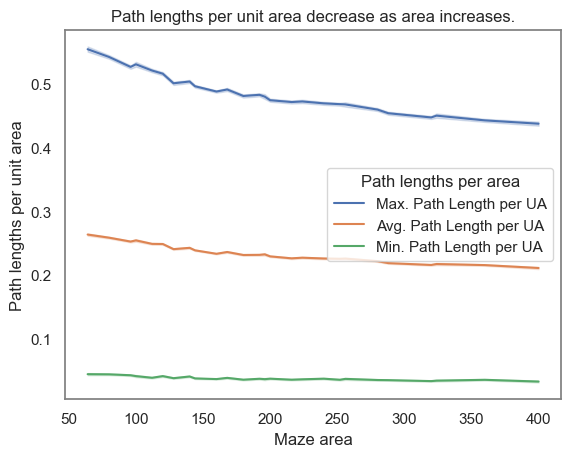

In [19]:
sns.lineplot(data=df, x="MazeArea", y="PathlengthMaxPerArea", label="Max. Path Length per UA")
sns.lineplot(data=df, x="MazeArea", y="PathlengthMeanPerArea", label="Avg. Path Length per UA")
sns.lineplot(data=df, x="MazeArea", y="PathlengthMinPerArea", label="Min. Path Length per UA")

plt.title("Path lengths per unit area decrease as area increases.")
plt.xlabel("Maze area")
plt.ylabel("Path lengths per unit area")
plt.legend(title="Path lengths per area")

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.savefig(
    "./output/pathlengths_per_area.png", dpi=300, bbox_inches="tight"
)

Bei steigenden Flächen werden somit mehr Sackgassen erzeugt, wodurch die Pfadlängen sinken, wobei das offensichtlich kein perfekt linearer Zusammenhang ist. 

Gleichzeitig steigt die Wanddichte, da mehr Wände pro Feld gesetzt werden können. 
Daraus ergibt sich die hohe Korrelation zwischen der Wanddichte und der durchschnittlichen/maximalen Pfadlänge mit einem Wert von ca. 0,8.

### Anzahl der bewegten Felder

#### Bewegte Felder x offensichtliche Parameter

Die Anzahl der bewegten Felder "Tiles moved" steigt natürlich mit der Höhe und Breite des Labyrinths an, wie das auch die Korrelationsmatrix bestätigt. 

Wie zuvor gefolgert, steigen die maximalen und durchschnittlichen Pfadlängen mit höheren Wanddichten an. Diese Pfadlängen - als Anzahl der Felder von jeder Safezone zu jedem Überlebenden definiert - führen somit direkt zu einer Erhöhung der Anzahl der bewegten Felder. Somit korrelieren die Wanddichte, sowie die maximale und durchschnittliche Pfadlänge mit der Anzahl der bewegten Felder.

#### Bewegte Felder x Anzahl Überlebende

Offensichtlich steigt die Anzahl der bewegten Felder mit der Anzahl der Überlebenden an.
Leicht auffällig ist dabei die minimale Degressivität des Graphen bei steigender Anzahl der Überlebenden.

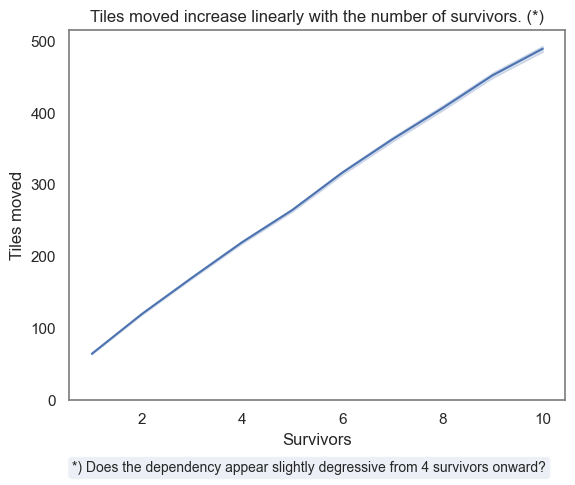

In [20]:
sns.lineplot(data=df, x="n_survivors", y="TotalTilesMoved")

plt.title("Tiles moved increase linearly with the number of survivors. (*)")
plt.xlabel("Survivors")
plt.ylabel("Tiles moved")

plt.ylim(bottom=0)
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.figtext(
    0.5,
    -0.04,
    "*) Does the dependency appear slightly degressive from 4 survivors onward?",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

plt.savefig("./output/tiles_moved_per_survivor.png", dpi=300, bbox_inches="tight")

Eine Vermutung für den leichten Abfall der linearen Abhängigkeit der bewegten Felder von der Anzahl der Überlebenden wäre, dass die Roboter bei mehr Überlebenden generell kürzere Pfade finden können, da es auch mehr Auswahlmöglichkeiten gibt.

Bestätigen könnte man diese These, wenn eine erhöhte Anzahl Überlebenden pro bewegten Feldern einen reduzierenden Effekt auf die bewegten Felder und somit die Pfadlängen haben sollten.

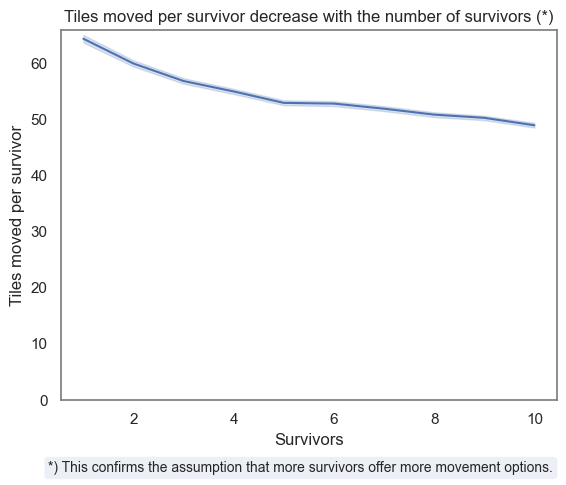

In [21]:
sns.lineplot(data=df, x="n_survivors", y="TilesMovedPerSurvivor")

plt.title("Tiles moved per survivor decrease with the number of survivors (*)")
plt.xlabel("Survivors")
plt.ylabel("Tiles moved per survivor")

plt.ylim(bottom=0)
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.figtext(
    0.5,
    -0.04,
    "*) This confirms the assumption that more survivors offer more movement options.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

plt.savefig("./output/tiles_moved_per_survivor_on_survivor.png", dpi=300, bbox_inches="tight")

Es wird Erkenntlich, dass mehr Überlebende generell zu weniger bewegten Feldern pro Überlebenden führen.
Das lässt sich auch mit der Anzahl der Safezones beweisen, die die optimalen Pfadlängen zwischen Roboter (startend von den Safezones) und den Überlebenden mindern.

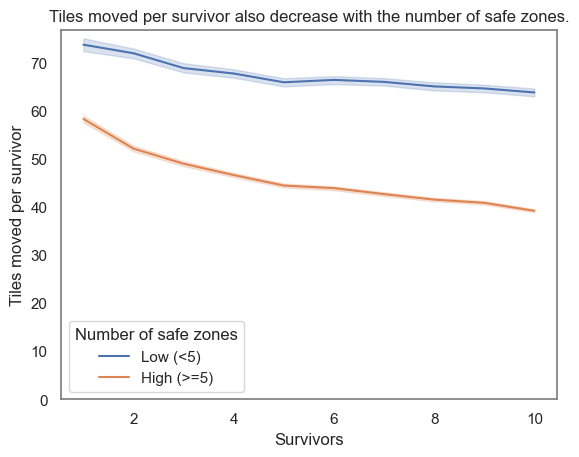

In [22]:
sns.lineplot(data=df, x="n_survivors", y="TilesMovedPerSurvivor", hue="SafeZoneCountGroup")

plt.title("Tiles moved per survivor also decrease with the number of safe zones.")
plt.xlabel("Survivors")
plt.ylabel("Tiles moved per survivor")

plt.ylim(bottom=0)
plt.legend(title="Number of safe zones")
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.savefig("./output/tiles_moved_per_survivor_on_safezones.png", dpi=300, bbox_inches="tight")

Aus der Grafik wird ersichtlich, dass mehr Safezones (>=5) zu einer Reduzierung der bewegten Felder pro Überlebenden führen.

Fraglich dabei ist, ob die Anzahl der Roboter auch einen positiven Einfluss auf die Pfadlängen hat. Die Vermutung wäre, dass sich Roboter wegen des gegenseitigen Wegnehmens des nähesten Überlebenden im Allgemeinen mehr bewegen müssen, schließlich steigen die Pfadlängen, wenn eine weniger optimale Lösung mit dem A-Stern Algorithmus gefunden wird.

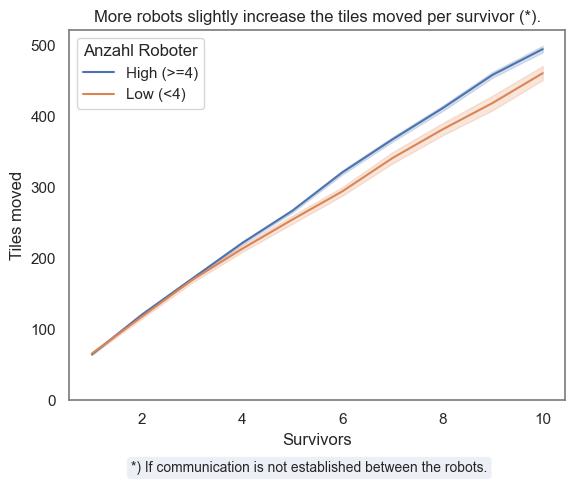

In [23]:
sns.lineplot(data=df, x="n_survivors", y="TotalTilesMoved", hue="RobotCountGroup")
plt.title("More robots slightly increase the tiles moved per survivor (*).")
plt.xlabel("Survivors")
plt.ylabel("Tiles moved")
plt.ylim(bottom=0)

plt.legend(title="Anzahl Roboter")
plt.figtext(
    0.5,
    -0.04,
    "*) If communication is not established between the robots.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.savefig(
    "./output/tiles_moved_per_survivor_grouped_robots.png", dpi=300, bbox_inches="tight"
)

Offensichtlich läuft die Simulation mit weniger Simulationsschritten ab, da mehr Roboter zur Verfügung stehen.

Die insgesamte Anzahl der bewegten Felder als Summe der zurückgelegten Felder pro Roboter steigt jedoch ab einer Anzahl von 4 Robotern leicht an.
Das bestätigt die Vermutung, dass die Roboter sich gegenseitig die optimalen Überlebenden und somit kürzesten Pfade wegnehmen. Bei einer Realwelt-Implementierung sollte deshalb auf geeigntete Kommunikation und Koordination zwischen den Robotern geachtet werden, um die Suchzeit zu reduzieren.

Mehr Roboter haben somit keinen positiven Einfluss auf die Pfadlängen, sondern erhöhen diese sogar wahrnehmbar.

### Simulationsschritte x Roboter

Natürlich sinkt die Anzahl der Simulationsschritte mit steigender Anzahl der Roboter, da die Überlebenden von mehreren Robotern gleichzeitig gerettet werden können.
In diesem Sinne halbiert sich die Anzahl der Simulationsschritte mit doppelter Anzahl von Robotern, wenn die Anzahl der Übelebenden nur groß genug ist. Das zeigt sich beispielsweise im Graphen im Schritt von einen auf zwei Robotern.

Bei sehr vielen oder mehr Robotern als Überlebenden, nähern sich die Simulationsschritte dem Wert 4 an. Das folgt aus der Folge der minimal vier Aktionen der Roboter:

- zu Überlebenden bewegen
- Überlebenden aufsammeln
- zu Safezone bewegen
- Überlebenden absetzen, Wiederhole von Anfang.

In realen Rettungsszenarien sollten daher die Prozesse bestmöglich optimiert werden, um die Überlebendenrettung zu beschleunigen. Gleichzeitig ist die Anzahl der Rettungskräfte (Agenten) entscheidend.

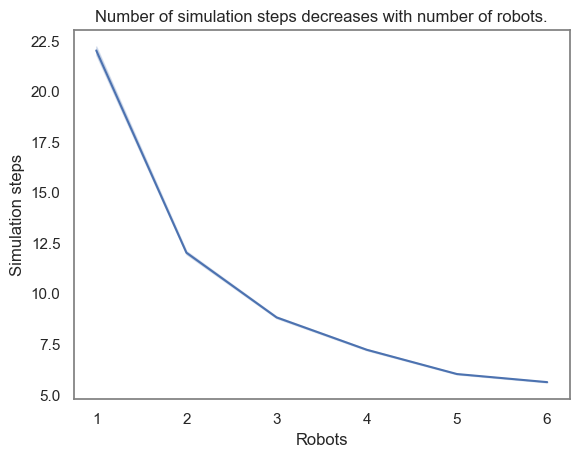

In [24]:
sns.lineplot(data=df, x="n_robot_agents", y="Step")

plt.title("Number of simulation steps decreases with number of robots.")
plt.xlabel("Robots")
plt.ylabel("Simulation steps")

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.savefig(
    "./output/simulationsteps_per_agent.png",
    dpi=300,
    bbox_inches="tight",
)

### Pfadlängen x Safezones

Auch sinken die minimalen Pfadlängen zwischen Safezones und Überlebenden mit steigender Anzahl der Safezones, da mehr Möglichkeiten für kürzere (optimale) Pfade zur Verfügung stehen.
Gleichzeitig steigen die maximalen Pfadlängen an, da die längsten (inoptimalsten) Pfade wahrscheinlicher werden. 
Dennoch profitiert der Roboter bei der Katastrophenrettung von einer höheren Anzahl an Safezones, da es mehr kürzere (optimale) Pfade gibt, die genutzt werden können.

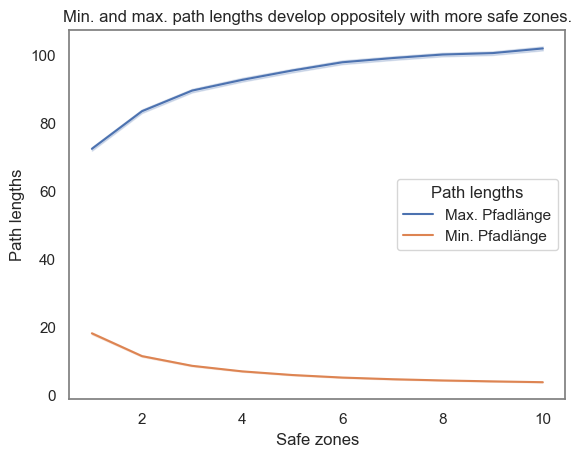

In [25]:
sns.lineplot(data=df, x="n_safe_zones", y="PathlengthMax", label="Max. Pfadlänge")
sns.lineplot(data=df, x="n_safe_zones", y="PathlengthMin", label="Min. Pfadlänge")

plt.title("Min. and max. path lengths develop oppositely with more safe zones.")
plt.xlabel("Safe zones")
plt.ylabel("Path lengths")

plt.legend(title="Path lengths")

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.savefig(
    "./output/safezones_maxpathlengths_grouped_survivors.png",
    dpi=300,
    bbox_inches="tight",
)

In wirklichen Rettungsszenarien sollte deshalb darauf geachtet werden, nicht zu wenige Safezones zu allokieren, um die Pfadlängen und damit die bewegte Distanz der Roboter zu minimieren.

### Optimierung der Safezone-Platzierung
Eine Hypothese im Simulationsbeispiel war, dass isolierte Safezones, also Safezones, die eine vergleichsweise hohe Pfadlänge zu anderen Safezones haben, am Ende der Simulation oftmals eine Großzahl an Überlebenden beherbergen.

Eine isolierte Safezone müsste dabei die Safezone sein, die maximal weit von anderen Safezones entfernt ist - die minimale Pfadlänge müsste somit am größten sein.
Um diese Hypothese zu überprüfen, müssten die Pfadlängen zwischen den Safezones und die schließlich geretteten Überlebendenpositionen analysiert werden.

Aus jeder durchgeführten Simulation werden zu jeder Safezone im Labyrinth alle relevanten Daten gesammelt.
Besonders die Berechnung der Pfadlängen führt hier zu einem hohen Rechenaufwand, sodass die Datenaggregation viel Zeit in Anspruch nimmt.

In [26]:
# TODO: Angebebene Werte in den Texten überschreiben

In [27]:
df_sz = pd.DataFrame()

# calculation time: up to 2.6 seconds per row! e.g. 5000 rows -> ~27min
# sample only 10% of rows for performance
n_samples = int(len(df) * 0.05)
print("Total samples:", n_samples)

start_time = time.time()
row_index = 0

if run_batch:
    for i, row in df.sample(n_samples).iterrows():
                
        # every 5%, print progress
        if row_index % (n_samples // 20) == 0:
            print(
                f"Processing row {row_index} of {n_samples} ({(row_index / n_samples) * 100:.2f}%)"
                + f" Time elapsed: {round((time.time() - start_time) / 60, 2)} minutes"
            )

        for sz in row["SafeZones"]:

            tmp_s = pd.Series()
            tmp_s["index"] = len(df_sz)
            tmp_s["x"] = sz.tile.x
            tmp_s["y"] = sz.tile.y
            tmp_s["MazeWidth"] = row["width"]
            tmp_s["MazeHeight"] = row["height"]
            tmp_s["totalSafeZones"] = len(row["SafeZones"])
            tmp_s["totalSurvivors"] = len(row["Survivors"])
            other_sz: List[SafeZone] = [s for s in row["SafeZones"] if s != sz]

            # euklidean distances to other safe zones
            tmp_s["EuDstSZs"] = [
                euklidean_distance((sz.tile.x, sz.tile.y), (s.tile.x, s.tile.y))
                for s in other_sz
            ]

            if tmp_s["EuDstSZs"]:
                tmp_s["EuDstSZMin"] = min(tmp_s["EuDstSZs"])
                tmp_s["EuDstSZMax"] = max(tmp_s["EuDstSZs"])
                tmp_s["EuDstSZMean"] = sum(tmp_s["EuDstSZs"]) / len(tmp_s["EuDstSZs"])
                tmp_s["EuDstSZMedian"] = pd.Series(tmp_s["EuDstSZs"]).median()
                tmp_s["EuDstSZStdDev"] = pd.Series(tmp_s["EuDstSZs"]).std()
            else:
                tmp_s["EuDstSZMin"] = 0
                tmp_s["EuDstSZMax"] = 0
                tmp_s["EuDstSZMean"] = 0
                tmp_s["EuDstSZMedian"] = 0
                tmp_s["EuDstSZStdDev"] = 0

            # manhattan distances to other safe zones
            tmp_s["MhDstSZs"] = [
                manhattan_distance((sz.tile.x, sz.tile.y), (s.tile.x, s.tile.y))
                for s in other_sz
            ]

            if tmp_s["MhDstSZs"]:
                tmp_s["MhDstSZMin"] = min(tmp_s["MhDstSZs"])
                tmp_s["MhDstSZMax"] = max(tmp_s["MhDstSZs"])
                tmp_s["MhDstSZMean"] = sum(tmp_s["MhDstSZs"]) / len(tmp_s["MhDstSZs"])
                tmp_s["MhDstSZMedian"] = pd.Series(tmp_s["MhDstSZs"]).median()
                tmp_s["MhDstSZStdDev"] = pd.Series(tmp_s["MhDstSZs"]).std()
            else:
                tmp_s["MhDstSZMin"] = 0
                tmp_s["MhDstSZMax"] = 0
                tmp_s["MhDstSZMean"] = 0
                tmp_s["MhDstSZMedian"] = 0
                tmp_s["MhDstSZStdDev"] = 0

            # pathlengths to other safe zones
            tmp_s["PathLengthSZs"] = EnvironmentModel.get_pathlengths_safezone_to_safezones(
                row["Maze"], sz, other_sz
            )

            if tmp_s["PathLengthSZs"]:
                tmp_s["PathLengthSZMin"] = min(tmp_s["PathLengthSZs"])
                tmp_s["PathLengthSZMax"] = max(tmp_s["PathLengthSZs"])
                tmp_s["PathLengthSZMean"] = sum(tmp_s["PathLengthSZs"]) / len(
                    tmp_s["PathLengthSZs"]
                )
                tmp_s["PathLengthSZMedian"] = pd.Series(tmp_s["PathLengthSZs"]).median()
                tmp_s["PathLengthSZStdDev"] = pd.Series(tmp_s["PathLengthSZs"]).std()
            else:
                tmp_s["PathLengthSZMin"] = 0
                tmp_s["PathLengthSZMax"] = 0
                tmp_s["PathLengthSZMean"] = 0
                tmp_s["PathLengthSZMedian"] = 0
                tmp_s["PathLengthSZStdDev"] = 0

            tmp_s["SurvivorsOnSZ"] = len(
                [
                    s
                    for s in row["Survivors"]
                    if s.tile.x == sz.tile.x and s.tile.y == sz.tile.y
                ]
            )
            tmp_s["SurvivorsOnSZRatio"] = (
                tmp_s["SurvivorsOnSZ"] / len(row["Survivors"])
                if row["Survivors"] else 0 
            )

            # concat
            df_sz = pd.concat([df_sz, tmp_s.to_frame().T])

        row_index +=1

    df_sz.set_index("index", inplace=True)

    print(f"Safezone DataFrame has {len(df_sz)} rows and {len(df_sz.columns)} columns.")
    df_sz.head(2)

else:
    df_sz = pd.read_pickle(SAFEZONE_DATA_PKL)
    print(f"Loaded Safezone DataFrame with {len(df_sz)} rows and {len(df_sz.columns)} columns.")

Total samples: 10290
Loaded Safezone DataFrame with 56642 rows and 32 columns.


In [28]:
df_sz["SurvivorCountGroup"] = df_sz.apply(
    lambda x: "Low (<5)" if x["totalSurvivors"] < 5 else "High (>=5)", axis=1
)
df_sz["SafeZoneCountGroup"] = df_sz.apply(
    lambda x: "Low (<5)" if x["totalSafeZones"] < 5 else "High (>=5)", axis=1
)
df_sz["EuDstSZMinRounded"] = df_sz.apply(
    lambda x: round(x["EuDstSZMin"] / 5) * 5, axis=1
)
df_sz["MhDstSZMinRounded"] = df_sz.apply(
    lambda x: round(x["MhDstSZMin"] / 5) * 5, axis=1
)
df_sz["PathLengthSZMinRounded"] = df_sz.apply(
    lambda x: round(x["PathLengthSZMin"] / 10) * 10, axis=1
)
min_width = df_sz["MazeWidth"].min()
max_width = df_sz["MazeWidth"].max()
df_sz["MazeWidthGroup"] = df_sz.apply(
    lambda x: (
        "Small"
        if x["MazeWidth"] < 0.5 * (max_width - min_width) + min_width
        else "Large"
    ),
    axis=1,
)

In [29]:
if run_batch:
    # safe to pickle file with the date and time appended
    df_sz.to_pickle(SAFEZONE_DATA_PKL)
    
df_sz.head(2)

,x,y,MazeWidth,MazeHeight,totalSafeZones,totalSurvivors,EuDstSZs,EuDstSZMin,EuDstSZMax,EuDstSZMean,...,PathLengthSZMedian,PathLengthSZStdDev,SurvivorsOnSZ,SurvivorsOnSZRatio,SurvivorCountGroup,SafeZoneCountGroup,EuDstSZMinRounded,MhDstSZMinRounded,PathLengthSZMinRounded,MazeWidthGroup
index,,,,,,,,,,,,,,,,,,,,,
0,0,16,18,20,9,7,"[13.0, 2.0, 17.09, 16.0, 4.24, 19.72, 12.0, 17.0]",2.0,19.72,12.63125,...,87.5,54.288745,3,0.428571,High (>=5),High (>=5),0,0,0,Large
1,0,3,18,20,9,7,"[13.0, 15.0, 6.71, 3.0, 16.28, 17.26, 1.0, 21.4]",1.0,21.4,11.70625,...,92.5,63.724295,0,0.0,High (>=5),High (>=5),0,0,0,Large


Ein Datenpunkt enthält Daten zu je einer Safezone inkl. genereller Labyrinthinformationen, euklidische und Manhattan Distanzen und Pfadlängen zu anderen Safezones (je aggregiert zu min, max, avg, ...), sowie der Anzahl der geretteten Überlebenden auf der Safezone.

#### Korrelationen der Safezone-Daten
Aus den verschiedenen Metriken wird eine Heatmap erstellt; die Korrelationen werden mittels des Pearson-Koeffizienten ermittelt.

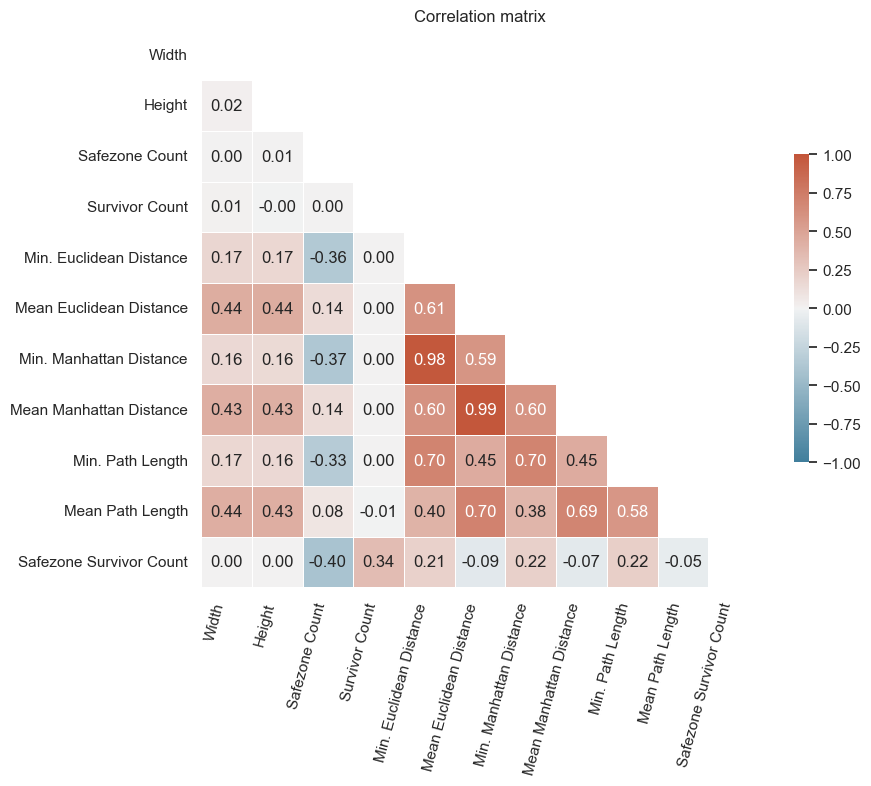

In [30]:
df_sz_corr = df_sz.reset_index()
df_sz_corr.drop(
    [
        "index",
        "EuDstSZs",
        "EuDstSZMinRounded",
        "EuDstSZMedian",
        "EuDstSZMax",
        "EuDstSZStdDev",
        "MhDstSZs",
        "MhDstSZMinRounded",
        "MhDstSZMedian",
        "MhDstSZStdDev",
        "MhDstSZMax",
        "PathLengthSZs",
        "PathLengthSZMinRounded",
        "PathLengthSZMedian",
        "PathLengthSZStdDev",
        "PathLengthSZMax",
        "x",
        "y",
        "SurvivorCountGroup",
        "SafeZoneCountGroup",
        "MazeWidthGroup",
        "SurvivorsOnSZRatio",
    ],
    axis=1,
    inplace=True,
    errors="ignore",
)

df_sz_corr.rename(
    columns={
        "MazeWidth": "Width",
        "MazeHeight": "Height",
        "totalSafeZones": "Safezone Count",
        "totalSurvivors": "Survivor Count",
        "EuDstSZMin": "Min. Euclidean Distance",
        "EuDstSZMean": "Mean Euclidean Distance",
        "MhDstSZMin": "Min. Manhattan Distance",
        "MhDstSZMean": "Mean Manhattan Distance",
        "PathLengthSZMin": "Min. Path Length",
        "PathLengthSZMean": "Mean Path Length",
        "SurvivorsOnSZ": "Safezone Survivor Count",
    }, 
    inplace=True,
)

sz_corr = df_sz_corr.corr()

# Correlation matrix with mask for upper triangle
sns.set_theme(style="white")
mask = np.triu(np.ones_like(sz_corr, dtype=bool))

f, ax = plt.subplots(figsize=(9, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    sz_corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True,
    fmt=".2f",
)
plt.title("Correlation matrix")
plt.xticks(rotation=75, ha="right")
plt.savefig("./output/safezonedata_corr_heatmap.png", dpi=300, bbox_inches="tight")

Speziell für die wichtigsten Werte (minimale euklidische und Manhattan Distanz, minimale Pfadlänge, Anzahl der geretteten Überlebenden) wird pro Metrik (Pearson, Kendall, Spearman) eine Heatmap erstellt.

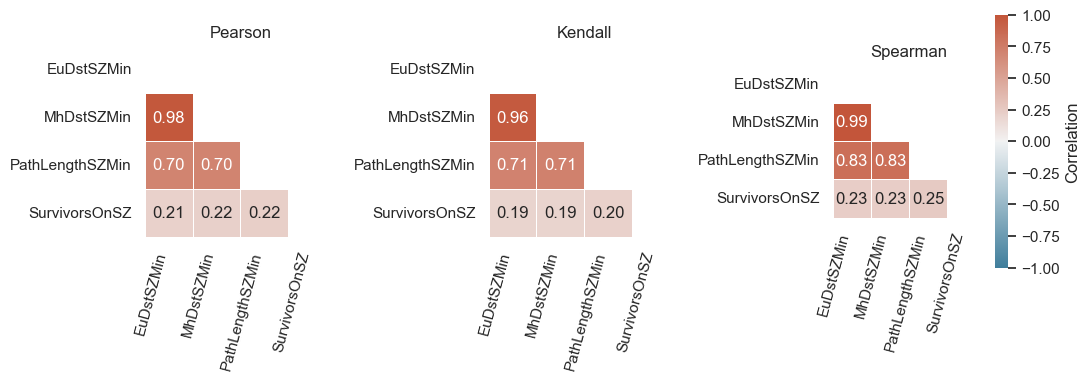

In [31]:
corr_pearson = df_sz[
    ["EuDstSZMin", "MhDstSZMin", "PathLengthSZMin", "SurvivorsOnSZ"]
].corr(method="pearson")
corr_kendall = df_sz[
    ["EuDstSZMin", "MhDstSZMin", "PathLengthSZMin", "SurvivorsOnSZ"]
].corr(method="kendall")
corr_spearman = df_sz[
    ["EuDstSZMin", "MhDstSZMin", "PathLengthSZMin", "SurvivorsOnSZ"]
].corr(method="spearman")

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)


def plot_corr_heatmap(ax, corr, title, mask, cmap, show_cbar=False):
    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmax=1,
        vmin=-1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar=show_cbar,
        cbar_kws={"label": "Correlation"} if show_cbar else None,
        annot=True,
        fmt=".2f",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha="right")


corrs = [
    (corr_pearson, "Pearson"),
    (corr_kendall, "Kendall"),
    (corr_spearman, "Spearman"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for i, (corr, title) in enumerate(corrs):
    plot_corr_heatmap(axes[i], corr, title, mask, cmap, show_cbar=(i == 2))

plt.tight_layout()
plt.show()

In der folgenden Tabelle sind die relevanten Werte aus der **Korrelationsmatrix** zusammengefasst. Zwischen der Anzahl der geretteten Überlebenden auf der Safezone und der jeweiligen Metrik werden die linearen Korrelationen mit Pearson r, sowie die rangbasierten Korrelationen mit Kendall tau und Spearman rho angegeben.

Ungefähre Korrelationswerte der jeweiligen Metriken: 
| Metrik | Pearson r | Kendall tau | Spearman rho |
|------|------|------|-----|
| Euklidische Distanz | 0.19 | 0.17 | 0.21 |
| Manhattan Distanz | 0.22 | 0.19 | 0.23 |
| Minimale Pfadlänge | 0.21 | 0.20 | 0.25 |


Wegen der linearen Art der Beziehung, sollte der Pearson Koeffizient r den rangbasierten Koeffizienten rho von Spearman und tau von Kendall in der Genauigkeit überlegen sein [vgl. hauke2011comparison]. Falls jedoch die rangbasierten Koeffizienten zum Vergleich verwendet werden würden, so sollte kein signifikanter Unterschied festzustellen sein [vgl. puth2015effective]. 

#### Überlebende auf der Safezone x minimale Pfadlänge
Veranschaulicht man die geretteten Überlebenden auf der Safezone in Abhängigkeit von der minimalen Pfadlänge, so zeigt sich ein Zusammenhang, der jedoch starke Abweichungen aufweist.

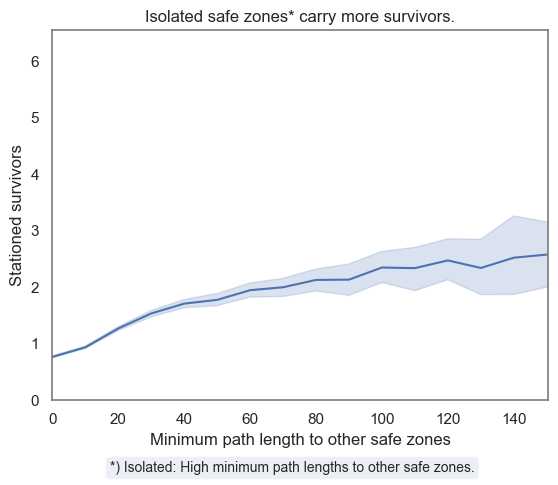

In [32]:
sns.lineplot(
    data=df_sz,
    x="PathLengthSZMinRounded",
    y="SurvivorsOnSZ",
)

plt.title("Isolated safe zones* carry more survivors.")
plt.xlabel("Minimum path length to other safe zones")
plt.ylabel("Stationed survivors")

plt.ylim(bottom=0)
plt.xlim(left=0)
plt.xlim(right=0.7 * df_sz["PathLengthSZMin"].max())
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.figtext(
    0.5,
    -0.04,
    "*) Isolated: High minimum path lengths to other safe zones.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

plt.savefig("./output/isolated_safezone_min_pathlength.png", dpi=300, bbox_inches="tight")

Offensichtlich sind die Korrelationswerte nicht ausschlaggebend hoch, jedoch genug, um einen gewissen Zusammenhang zu bestätigen.
Zudem bestätigt die oben gezeigte Grafik diese Beziehung zwischen der Isolation einer Safezone und den letztendlich getragenen Überlebenden.

Interessant sind die **hohen Abweichungen** in der Abbildung, die sich wie folgt zusammensetzen:
In den Messungen hat der Median der minimalen Pfadlängen den Wert 6.00, den Durchschnitt 12,76 und eine besonders hohe Standardabweichung von 18,55. Das erklärt maßgeblich die abgebildete Varianz des Zusammenhangs. Wegen des besonders hohen Rechenaufwands sind bisher nur Teile der gesamten Daten analysierbar. Eine Effizienzsteigerung könnte zu neuen Erkenntnissen führen, wie beispielsweise geringeren Abweichungen.

In [33]:
print("Durchschnitt der minimalen Pfadlängen:", round(df_sz["PathLengthSZMin"].mean(), 2))
print("Median der minimalen Pfadlängen:", round(df_sz["PathLengthSZMin"].median(), 2))
print("Standardabweichung der minimalen Pfadlängen:", round(df_sz["PathLengthSZMin"].std(), 2))

Durchschnitt der minimalen Pfadlängen: 12.63
Median der minimalen Pfadlängen: 6.0
Standardabweichung der minimalen Pfadlängen: 18.44


Erfolgt die Platzierung einer Safezone in möglichst weiter Entfernung zu anderen Safezones, so beherbergt sie bis zum Ende der Simulation durchschnittlich mehr Überlebende als andere Safezones, die nicht isoliert platziert wurden. Mehr gerettete Überlebende in einer Sicherheitszone bedeuten, dass diese Zone öfter bei der Wahl des effizientesten Pfades gewählt wurde. Die insgesamt bewegten Felder der Agenten in der Simulation sinken folglich, da effizientere Pfade gewählt werden können.

Eine Optimierung der Safezone-Platzierung ohne Informationen zu den Positionen der Überlebenden sähe somit wie folgt aus: *Platziere die Safezones derart, sodass sie jeweils möglichst weit voneinander entfernt sind.*

Es ist die Kombination der Safezone-Positionen zu suchen, die die minimalen Pfadlängen zu anderen Safezones maximiert. Im schlechtesten Fall würde die Simulation zwei Safezones in direkt angrenzenden, begehbaren Feldern platzieren, wodurch sich die beiden Safezones im Grunde zu einer einzelnen Safezone mit ggf. kleiner Abweichung gruppieren ließen. 

Generell lassen sich einige **Erkenntnisse für ein Realweltszenario** in labyrinthähnlichen Gebieten ableiten:
Um die im Rettungsszenario benötigte Zeit und den Weg zu minimieren, sollten die Rettungszonen möglichst weite Pfade zueinander besitzen, sodass eine Wegfindung bestmöglich optimiert werden kann.

Fraglich ist, ob bei einer nicht bekannten Struktur des Labyrinths, jedoch bekannter Größe, die Platzierung der Rettungszonen auch **mittels eines einfachen Abstands ohne Pfaden** erfolgen kann.

#### Überlebende auf der Safezone x gemessene Distanzen
In realen Szenarien ist die Struktur des Katastrophengebiets, das hier als Labyrinth modelliert wird, eventuell nicht bekannt.
Daher müsste die Platzierung der Safezones auch ohne initiale Pfadfindung erfolgen können. Dazu werden einerseits die euklidische Distanz als auch die Manhattan Distanz zwischen den Safezones betrachtet, um die Machbarkeit eines ungefähren Augenmaßes beim Platzieren zu überprüfen.

Bestenfalls würden die Daten zeigen, dass das Platzieren der Rettungszonen mit möglichst großen Pfadlängen zueinander rein durch die gemessenen absoluten Distanzen - als grobes Augenmaß - zwischen ihnen erfolgen kann.

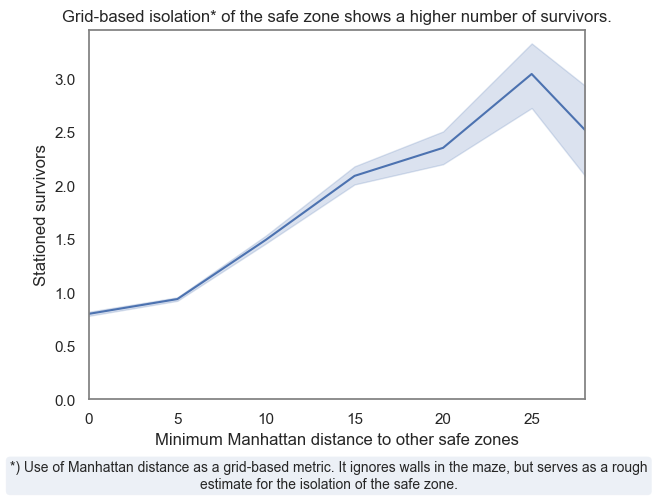

In [34]:
sns.lineplot(data=df_sz, x="MhDstSZMinRounded", y="SurvivorsOnSZ")

plt.title("Grid-based isolation* of the safe zone shows a higher number of survivors.")
plt.xlabel("Minimum Manhattan distance to other safe zones")
plt.ylabel("Stationed survivors")

plt.xlim(right=0.8 * max(df_sz["MhDstSZMinRounded"]))
plt.xlim(left=0)
plt.ylim(bottom=0)
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.figtext(
    0.5,
    -0.07,
    "*) Use of Manhattan distance as a grid-based metric. It ignores walls in the maze, but serves as a rough estimate for the isolation of the safe zone.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

plt.savefig(
    "./output/isolated_safezone_min_manhdist.png", dpi=300, bbox_inches="tight"
)

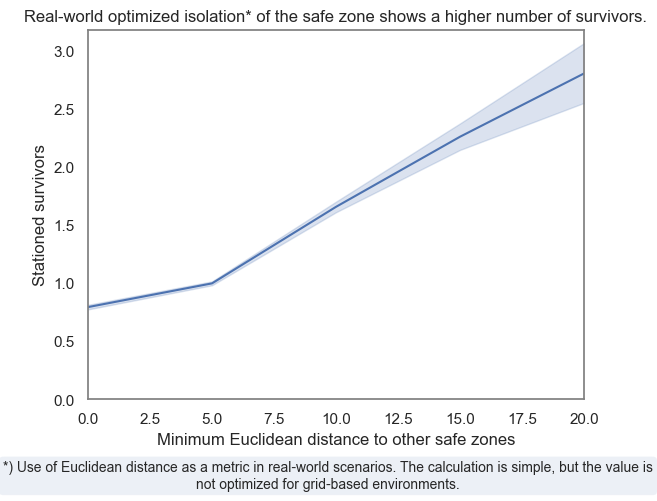

In [35]:
sns.lineplot(data=df_sz, x="EuDstSZMinRounded", y="SurvivorsOnSZ")

plt.title("Real-world optimized isolation* of the safe zone shows a higher number of survivors.")
plt.xlabel("Minimum Euclidean distance to other safe zones")
plt.ylabel("Stationed survivors")

plt.xlim(right=0.8 * max(df_sz["EuDstSZMinRounded"]))
plt.xlim(left=0)
plt.ylim(bottom=0)
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.figtext(
    0.5,
    -0.07,
    "*) Use of Euclidean distance as a metric in real-world scenarios. The calculation is simple, but the value is not optimized for grid-based environments.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

plt.savefig("./output/isolated_safezone_min_eukldist.png", dpi=300, bbox_inches="tight")

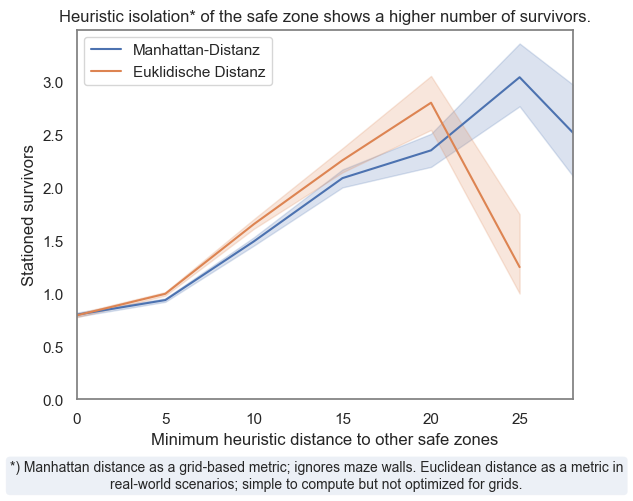

In [36]:
sns.lineplot(data=df_sz, x="MhDstSZMinRounded", y="SurvivorsOnSZ", label="Manhattan-Distanz")
sns.lineplot(data=df_sz, x="EuDstSZMinRounded", y="SurvivorsOnSZ", label="Euklidische Distanz")

plt.title("Heuristic isolation* of the safe zone shows a higher number of survivors.")
plt.xlabel("Minimum heuristic distance to other safe zones")
plt.ylabel("Stationed survivors")

plt.xlim(right=0.8 * max(df_sz["MhDstSZMinRounded"]))
plt.xlim(left=0)
plt.ylim(bottom=0)
for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.figtext(
    0.5,
    -0.07,
    "*) Manhattan distance as a grid-based metric; ignores maze walls. Euclidean distance as a metric in real-world scenarios; simple to compute but not optimized for grids.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

plt.savefig("./output/isolated_safezone_min_both_heuristics.png", dpi=300, bbox_inches="tight")

Aus den Grafiken der minimalen Manhattan, bzw. euklidischen, Distanz zwischen den Safezones wird ersichtlich, dass selbst das grobe Augenmaß für Abstände zwischen den Safezones ausreichen kann, um die minimale Pfadlänge zu anderen Safezones zu maximieren und somit die bewegten Felder durch die Agenten zu reduzieren.

Die Grid-basierte Distanz ist vor allem für die Simulation relevant, da sich hier nicht diagonal bewegt werden kann. In der Realität sind aber auch andere Bewegungsrichtungen möglich, sodass dort die euklidische Distanz verwendet werden sollte. Sie zeigt zwar im Vergleich der Grafiken und der Pearson-Korrelation einen leicht geringeren Zusammenhang, als die Manhattan Distanz, der Unterschied ist jedoch nicht besonders signifikant.

Deutlich wird allerdings auch bei den Distanzen, wie stark die auftretenden **Abweichungen** sind.
Bei der minimalen Manhattan Distanz liegt der Median bei 3.00, der Durchschnitt bei 4.38 und die Standardabweichung bei 4.10.
Die euklidische Distanz hat einen Median von 3.00, einen Durchschnitt von 3.90 und eine Standardabweichung von 3.34.
In folgender Tabelle sind die hohen Abweichungen nochmals zusammengefasst:

| Metrik | Median | Durchschnitt | Standardabweichung |
|------|------|------|-----|
| Minimale euklidische Distanz | 3.00 | 3.90 | 3.34 |
| Minimale Manhattan Distanz | 3.00 | 4.38 | 4.10 |
| Minimale Pfadlänge | 6.00 | 12.76 | 18.55 |

In [37]:
# TODO fill values for min distances (see values below) with more data!

In [38]:
print("Durchschnitt der minimalen euklidischen Distanzen:", round(df_sz["EuDstSZMin"].mean(), 2))
print("Median der minimalen euklidischen Distanzen:", round(df_sz["EuDstSZMin"].median(), 2))
print("Standardabweichung der minimalen euklidischen Distanzen:", round(df_sz["EuDstSZMin"].std(), 2))

print("\nDurchschnitt der minimalen Manhattan-Distanzen:", round(df_sz["MhDstSZMin"].mean(), 2))
print("Median der minimalen Manhattan-Distanzen:", round(df_sz["MhDstSZMin"].median(), 2))
print("Standardabweichung der minimalen Manhattan-Distanzen:", round(df_sz["MhDstSZMin"].std(), 2))

Durchschnitt der minimalen euklidischen Distanzen: 3.89
Median der minimalen euklidischen Distanzen: 3.0
Standardabweichung der minimalen euklidischen Distanzen: 3.29

Durchschnitt der minimalen Manhattan-Distanzen: 4.37
Median der minimalen Manhattan-Distanzen: 3.0
Standardabweichung der minimalen Manhattan-Distanzen: 4.04


Aus den gesammelten Erkenntnissen der Simulationen und der Auswertung der Safezones lässt sich für ein **Realweltszenario** folgendes ableiten:
- Im Falle einer bekannten Struktur des Katastrophengebiets, wie im simulierten Labyrinth, sollten die Rettungszonen zueinander möglichst lange Pfade haben, sodass die Agenten effizientere Wege finden können und die Suchzeit verringert werden kann.
- Sollte die Struktur des Gebiets vorab nicht bekannt sein, können die Rettungszonen auch mit einem groben Augenmaß mithilfe von maximal großen Abständen zwischen einander platziert werden. Die Abstände zwischen den Sicherheitszonen sollten für Grid-basierte Gebiete mithilfe der Manhattan Distanz, sonst aber mit der euklidischen Distanz berechnet werden.
- Unter keinen Umständen sollten Rettungszonen in Clustern, also nah bei einander, aufgestellt werden, da sie aus Sicht der Pfadfindung zu einer einzigen Rettungszone zusammengefasst werden können. Stattdessen sollten die Ressourcen für diese Rettungszonen verwendet werden, um sich in noch nicht abgedeckten Gebieten zu stationieren. Somit kann die Rettungszeit effektiv reduziert werden.

#### Potentielle (unfertige) Erweiterung: Isolierte Safezones -> Reduktion der bewegten Felder
to get the effect of maximizing the minimal pathlengths in between safezones, first we have to gurantee that the width and height are always the same, as they disturb the effectiveness of measured plots.

In [39]:
raise RuntimeError("Not implemented yet")

RuntimeError: Not implemented yet

In [ ]:
def min_sz_pathlength(row):
    maze = row["Maze"]
    safezones = row["SafeZones"]
    pathlengths = []
    for sz in safezones:
        lengths = EnvironmentModel.get_pathlengths_safezone_to_safezones(
            maze, sz, safezones
        )
        if lengths:
            pathlengths.append(min(lengths))
        else:
            continue
    return min(pathlengths) if pathlengths else 0


def total_sz_pathlength(row):  # berechnung evtl nicht richtig. TODO fixen
    maze = row["Maze"]
    safezones = row["SafeZones"]
    if len(safezones) < 2:
        return 0

    edges = len(safezones) * (len(safezones) - 1)  # /2 TODO: richtig?
    total = 0
    for sz in safezones:
        pathlengths = EnvironmentModel.get_pathlengths_safezone_to_safezones(
            maze, sz, safezones
        )
        total += sum(pathlengths)
    return total / edges

In [ ]:
# df has the column Safezones with a List of Safezone objects
# get_pathlengths_safezone_to_safezones can be called from each safezone to all other safezones using
# the parameters maze, safezone and all safezones
# all of the pathslengths shall be stored in the column "TotalSZPathlength"
# after that, calculate the pathlength per safezone into the column "TotalSZPathlengthPerSZ"
# Calculate the total pathlength between all pairs of Safezones for each row

# get min and max safezone count to reduce calculation time
print("Rows:", len(df))
min_sz_count: int = min(df["n_safe_zones"])
max_sz_count: int = max(df["n_safe_zones"])
df_test = df[(df["n_safe_zones"] == min_sz_count) | (df["n_safe_zones"] == max_sz_count)]

print("Reduced rows:", len(df_test))

# df_test["MinSZPathlength"] = df_test.apply(min_sz_pathlength, axis=1)
df_test["TotalSZPathlength"] = df_test.apply(total_sz_pathlength, axis=1)

# maybe flatten the points
# df_test["MinSZPathlengthFlattened"] = df_test.apply(
#     lambda x: round(x["MinSZPathlength"] / 2) * 2, axis=1
# )
df_test["TotalSZPathlengthFlattened"] = df_test.apply(
    lambda x: round(x["TotalSZPathlength"] / 5) * 5, axis=1
)

In [ ]:
# Distribution of the sum of the pathlengths
sns.histplot(df_test["TotalSZPathlength"])
df_test["TotalSZPathlength"].describe() 

In [ ]:
# Distribution of the min of the pathlengths
# sns.histplot(df_test["MinSZPathlength"])
# df_test["MinSZPathlength"].describe()

schöner formatieren

In [ ]:
# lmplot for 2 columns for the min & max n_safe_zones with each seperated MazeAreas
g = sns.lmplot(
    data=df_test[df_test["MazeArea"].apply(lambda n: int(np.sqrt(n)) ** 2 == n)],
    x="TotalSZPathlength",
    y="TotalTilesMoved",
    hue="MazeArea",
    markers="o",
    scatter_kws={"s": 9},
    palette="viridis", 
    legend=False,
    col="n_safe_zones",
    order=1
)

# descriptions
for ax, title in zip(g.axes.flat, sorted(df_test['n_safe_zones'].unique())):
    ax.set_title(f"Safezones: {title}")

g.set_axis_labels(
    "Summed path lengths between all safe zones", "Total tiles moved"
)
plt.suptitle(
    "More isolated safe zones* lead to a reduction in tiles moved.",
    y=1.05,
)
plt.legend(title="Maze area [tiles]:")

# limits
quantile_x_right = df_test["TotalSZPathlength"].quantile(0.96)
quantile_x_left = df_test["TotalSZPathlength"].quantile(0.2)
quantile_y_bottom = df_test["TotalTilesMoved"].quantile(0)
quantile_y_top = df_test["TotalTilesMoved"].quantile(0.97)

plt.xlim(left=quantile_x_left)
plt.xlim(right=quantile_x_right)
plt.ylim(top=quantile_y_top)
plt.ylim(bottom=quantile_y_bottom)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_color("gray")

plt.figtext(
    0.5,
    -0.07,
    f"*) Isolation measured by the sum of path lengths between all safe zones. Dependency on maze area and number of safe zones still exists. Total data points: {len(df_test)}.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.1),
)

plt.savefig("./output/tiles_moved_per_total_safezone_pathlengths.png", dpi=300, bbox_inches="tight")

In [ ]:
df_test_corr = df_test[["TotalSZPathlength", "TotalTilesMoved"]].corr()
df_test_corr